In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

X, y = fetch_california_housing(return_X_y=True)

In [3]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=1, test_size=.2)


In [5]:
vc = VotingRegressor([('knc',KNeighborsRegressor()),('logreg',LinearRegression())])
vc.fit(X_train, y_train)

VotingRegressor(estimators=[('knc', KNeighborsRegressor()),
                            ('logreg', LinearRegression())])

In [6]:
from sklearn.model_selection import KFold, cross_val_score

cross = cross_val_score(vc, X_train, y_train, scoring='neg_mean_squared_error')
-np.mean(cross)

np.float64(0.6717663477011155)

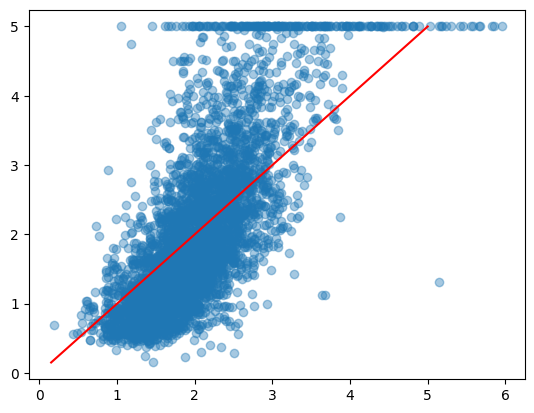

In [7]:
ypred = vc.predict(X_test)

import matplotlib.pyplot as plt

plt.scatter(ypred, y_test, alpha=.4)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], c='red')



In [8]:
import statsmodels.api as sm

ol = sm.OLS(y_train, X_train).fit()

Text(-2, -5, 'The Curve suggests that there is a non-linear \nrelationship between the target and one or more features')

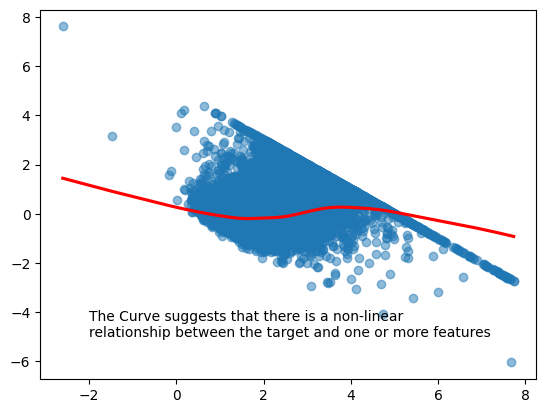

In [14]:
import seaborn as sns

sns.regplot(x=ol.fittedvalues, y=ol.resid, lowess=True, line_kws={'color':'red'}, scatter_kws={'alpha':.5})
plt.text(-2,-5,'The Curve suggests that there is a non-linear \nrelationship between the target and one or more features')